# Notebook Objective -  Visualize Reference Maps
1) scope of model (release locations)
2) nursery grounds

In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import os

from shapely.geometry import Point, Polygon as ShapelyPolygon
import matplotlib.pyplot as plt
import seaborn as sns

import importlib
import utils  # Importing the utils module

In [2]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
output_path = repo_path + 'processed_data/'
fig_path = repo_path + 'figures/'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Polygon
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as ticker
import cmocean
import cmocean.cm as cmo

import matplotlib.patheffects as path_effects
import matplotlib.colors as mcolors


In [4]:
# Import Utils for consistent naming, colors, labling, and mapping
importlib.reload(utils) # Run this if you update something in your utils file you need

# Import necessary data and functions from utils
hypotheses = utils.hypotheses
stages = utils.stages
locations = utils.locations
start_years = utils.start_years
months_data = utils.months_data
extents = utils.extents
bathymetry = utils.bathymetry

# function
plot_region = utils.plot_region
plot_contour = utils.plot_contour

In [5]:
importlib.reload(utils) # Run this if you update something in your utils file you need

boxes = {key: value['boxes'] for key, value in locations.items()}
location_labels = {key: value['label'] for key, value in locations.items()}
location_colors = {key: value['color'] for key, value in locations.items()}
location_order = {key: value['order'] for key, value in locations.items()}

# Different Hypotheses (in this case only hi res)
hypotheses = utils.hypotheses
hypotheses_name = {key: value['name'] for key, value in hypotheses.items()}
hypothesis_labels = {key: value['label'] for key, value in hypotheses.items()}
hypothesis_order = {key: value['order'] for key, value in hypotheses.items()}

start_years = utils.start_years
sy_labels = {key: value['label'] for key, value in start_years.items()}
sy_marker = {key: value['marker'] for key, value in start_years.items()}

extent = extents['hires']

In [6]:
# Helper function to plot the base map and all boxes
def plot_nurseries_bw(ax, extent, locations, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    # Plot all bounding boxes
    for region, loc_data in locations.items():
        for box in loc_data['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='k', zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)

# Helper function to plot the base map and all boxes
def plot_nurseries_bw_fill(ax, extent, locations, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    # Plot all bounding boxes
    for region, loc_data in locations.items():
        for box in loc_data['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=True, color ='k', alpha=0.1, zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)


# Helper function to plot the base map and specific nursery box
def plot_nurseries_individ(ax, extent, locations, nursery=None, box_zorder=6):
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    
    # If a specific nursery is provided, plot only that nursery
    if nursery in locations:
        loc_data = locations[nursery]
        for box in loc_data['boxes']:
            lonpoly = box['lonpoly']
            latpoly = box['latpoly']
            poly = Polygon(list(zip(lonpoly, latpoly)), closed=True, fill=False, edgecolor='k', zorder=box_zorder, transform=ccrs.PlateCarree())
            ax.add_patch(poly)
    else:
        print(f"Nursery '{nursery}' not found in locations.")

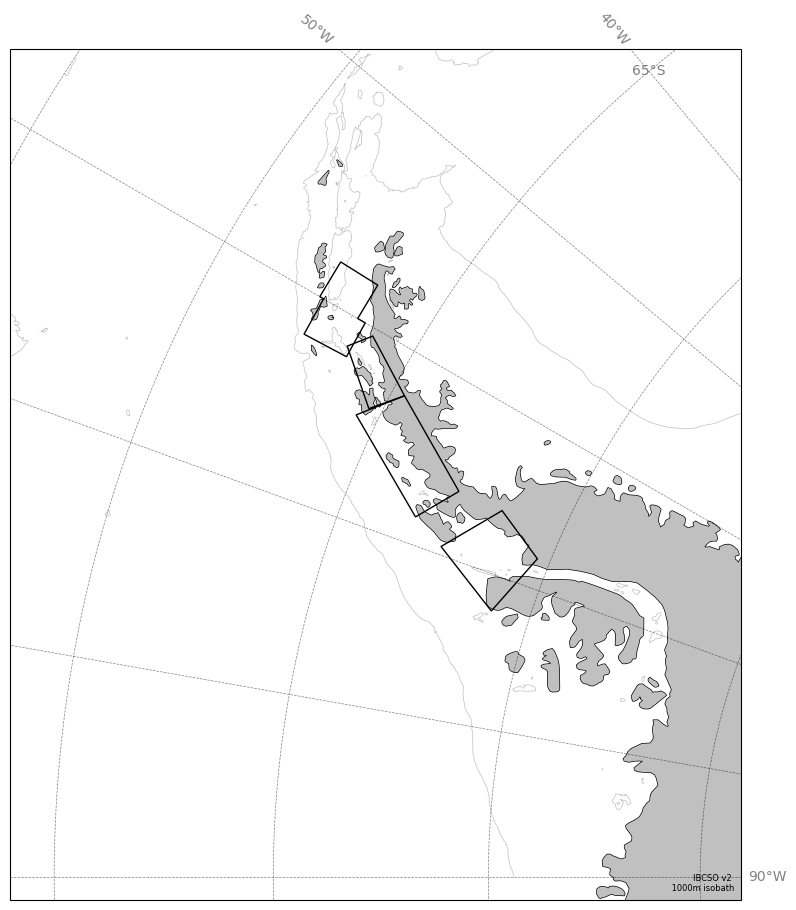

In [7]:
# Plot nursery grounds simple
fig, ax = plt.subplots(1, 1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})

plot_region(ax, extent)  # Sets up the map with coastline, land, gridlines, etc.
plot_contour(ax, extent)  # Plots the bathymetry contours
# plot_nurseries_individ(ax, extent, locations, nursery)  # Only plot the bounding box for the specific nursery
plot_nurseries_bw(ax, extent, locations)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [12]:
# File Paths to data
repo_path = '/Users/zephyrsylvester/repos/circumpolar-connectivity-analysis/'
data_path = repo_path + 'data/'
output_path = '/Users/zephyrsylvester/repos/hi-res-AP/circumpolar-connectivity-analysis/'
ibsco_path = data_path + 'IBSCO/'

fig_path = repo_path + 'figures/'
tab_path = fig_path + 'tables/'
map_path = fig_path + 'maps/'


# Path to the downloaded NetCDF file
nc_path = ibsco_path + 'IBCSO_v2_bed_WGS84.nc'

# Open the NetCDF file using xarray
ds = xr.open_dataset(nc_path)

# Crop the bathymetry data to focus on the Antarctic region
bathymetry = ds['z']

In [13]:

# Define grid spacing in degrees
grid_spacing_deg = 25 / 111.32  # Convert 25 km to degrees

# Define the extent of the Southern Ocean
lat_min, lat_max = -90, -50
lon_min, lon_max = -180, 180

# Generate grid points
lons = np.arange(lon_min, lon_max, grid_spacing_deg)
lats = np.arange(lat_min, lat_max, grid_spacing_deg)
lon_grid, lat_grid = np.meshgrid(lons, lats)


In [14]:
# Interpolate bathymetry data onto the grid
bathymetry_interpolated = bathymetry.interp(lon=lon_grid[0, :], lat=lat_grid[:, 0], method='linear')
bathymetry_interpolated

<xarray.DataArray 'z' (lat: 179, lon: 1604)> Size: 2MB
array([[           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan,    26.91343968,    25.91343968, ...,
           29.22779047,    28.63643459,            nan],
       [           nan,   355.45018616,   355.45018616, ...,
          352.89299011,   353.89299011,            nan],
       ...,
       [           nan, -4720.56361294, -4580.17157295, ...,
        -4441.63096009, -4423.44230134,            nan],
       [           nan, -4529.96592496, -4513.35681394, ...,
        -4405.50323723, -4416.24757454,            nan],
       [           nan, -4450.76579447, -4483.09343068, ...,
        -3799.4188289 , -3602.86163287,            nan]])
Coordinates:
  * lon      (lon) float64 13kB -180.0 -179.8 -179.6 ... 179.5 179.8 180.0
  * lat      (lat) float64 1kB -90.0 -89.78 -89.55 ... -50.47 -50.25 -50.03
Attributes:
    long_name:     elevation
    grid_mapping:  crs
    units:         m

In [15]:
# Filter grid points by seabed depth (e.g., seabed depth < 3000 meters)
depth_threshold = -3000  # Depth threshold (negative value for seabed)
valid_points = bathymetry_interpolated >= depth_threshold

# Apply the mask to lon and lat grids
filtered_lon = lon_grid[valid_points.values]
filtered_lat = lat_grid[valid_points.values]


In [16]:
# Define the cropping range for latitude and longitude
lat_range = slice(-75, -60)

# Crop the dataset by latitude and longitude
bathymetry_antcir = bathymetry.sel(lat=lat_range)


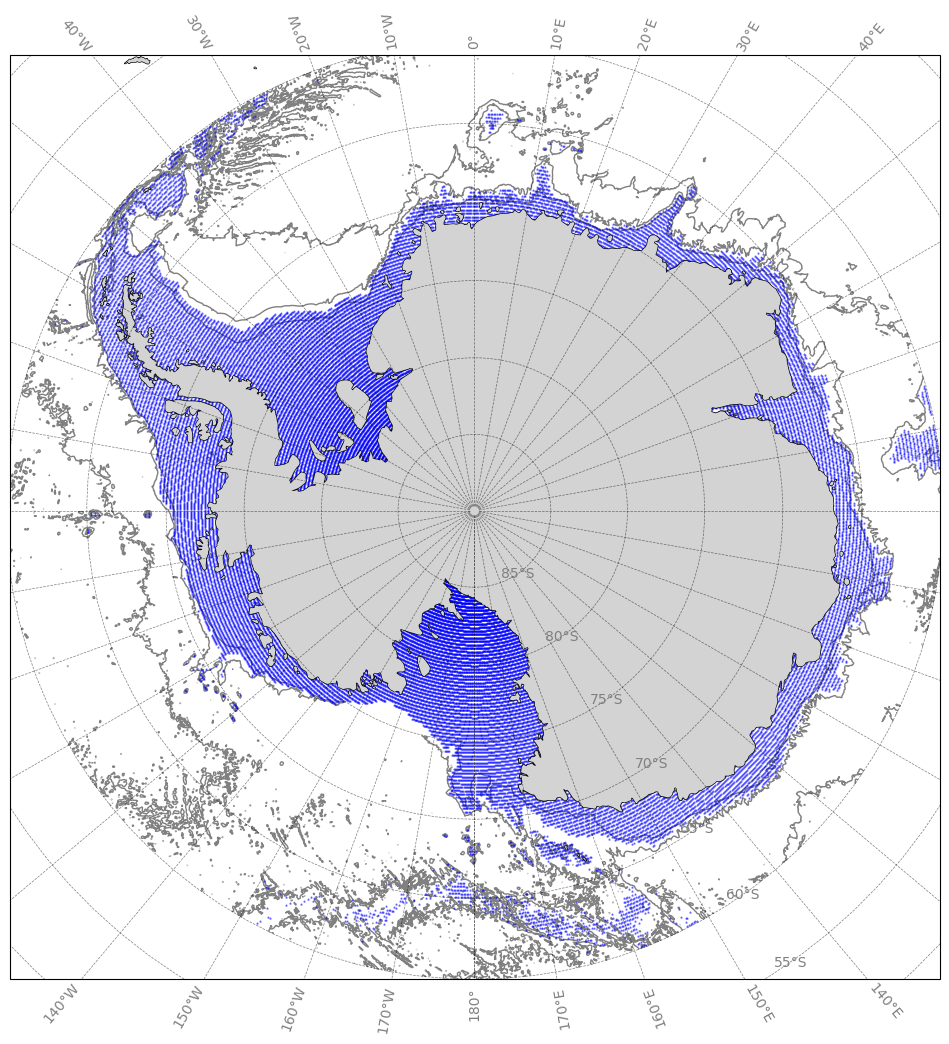

In [18]:
# Filter grid points by seabed depth and latitude cutoff
depth_threshold = -2500  # Seabed depth threshold
latitude_cutoff = -60    # Southern Ocean latitude cutoff

# Combine depth and latitude filters
valid_points = (bathymetry_interpolated >= depth_threshold) & (lat_grid <= latitude_cutoff)

# Apply the mask to lon and lat grids
filtered_lon = lon_grid[valid_points.values]
filtered_lat = lat_grid[valid_points.values]

# Plot the filtered grid
fig = plt.figure(figsize=(12, 12))
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())

# Add map features
ax.add_feature(cfeature.COASTLINE, zorder=2)
ax.add_feature(cfeature.LAND, facecolor='lightgrey', zorder=2)
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=1)
gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Plot bathymetry contours
contour = ax.contour(bathymetry_antcir['lon'], bathymetry_antcir['lat'], bathymetry_antcir,
                     linestyles='solid', linewidths=1, colors='grey',
                     transform=ccrs.PlateCarree(), zorder=0)

# Plot filtered grid points
ax.scatter(filtered_lon, filtered_lat, transform=ccrs.PlateCarree(), color='blue', s=0.5, alpha=0.5, marker='^', zorder=1)

# Set extent to focus on the Southern Ocean
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
# # Save the figure
# plt.savefig(map_path + 'circumpolar-release-grid-noice.png', dpi=200, bbox_inches='tight')

plt.show()

In [23]:
# Open Sea Ice Data
# Path to the downloaded NetCDF file
nc_path = data_path + 'NSIDC-0780_SeaIceRegions_EASE2-S25km_v1.0.nc'

# Open the NetCDF file using xarray
ds_ndic = xr.open_dataset(nc_path)

# Extract the ice mask variable
ice_mask = ds_ndic['sea_ice_region_NASA_surface_mask']

In [24]:
# Extract the ice shelf mask (region 34)
ice_shelf_flag = 34
ice_shelf_mask = ice_mask == ice_shelf_flag

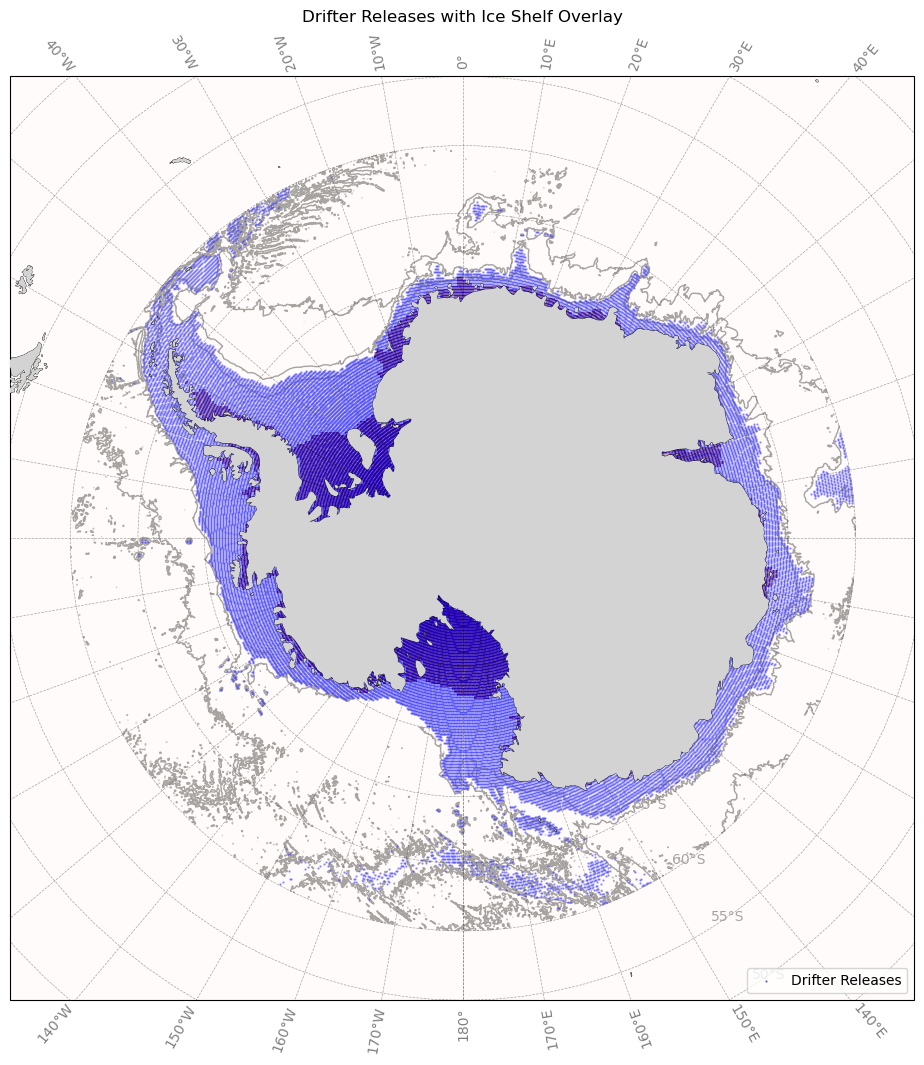

In [26]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Plot the drifter release grid with the ice shelf overlay
fig = plt.figure(figsize=(12, 12))
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)  # On top of ice shelf
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)  # On top of ice shelf
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=1)
gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Plot bathymetry contours
contour = ax.contour(bathymetry_antcir['lon'], bathymetry_antcir['lat'], bathymetry_antcir,
                     linestyles='solid', linewidths=1, colors='grey',
                     transform=ccrs.PlateCarree(), zorder=0)

# Plot the drifter release points (UNDER everything)
ax.scatter(
    filtered_lon, filtered_lat,
    transform=ccrs.PlateCarree(),
    color='blue', s=0.5, alpha=0.5, label='Drifter Releases', zorder=1
)

# Overlay the ice shelf mask (ON TOP of release points)
ice_plot = ax.pcolormesh(
    ds_ndic['x'], ds_ndic['y'], ice_shelf_mask,
    transform=ccrs.SouthPolarStereo(),
    cmap='Reds', alpha=0.3, zorder=2  # Semi-transparent red for ice shelves
)

# Add a legend
ax.legend(loc='lower right')

# Add a title
ax.set_title("Drifter Releases with Ice Shelf Overlay")

# Set the extent for the Southern Ocean
ax.set_extent([-180, 180, -90, -55], crs=ccrs.PlateCarree())

plt.show()

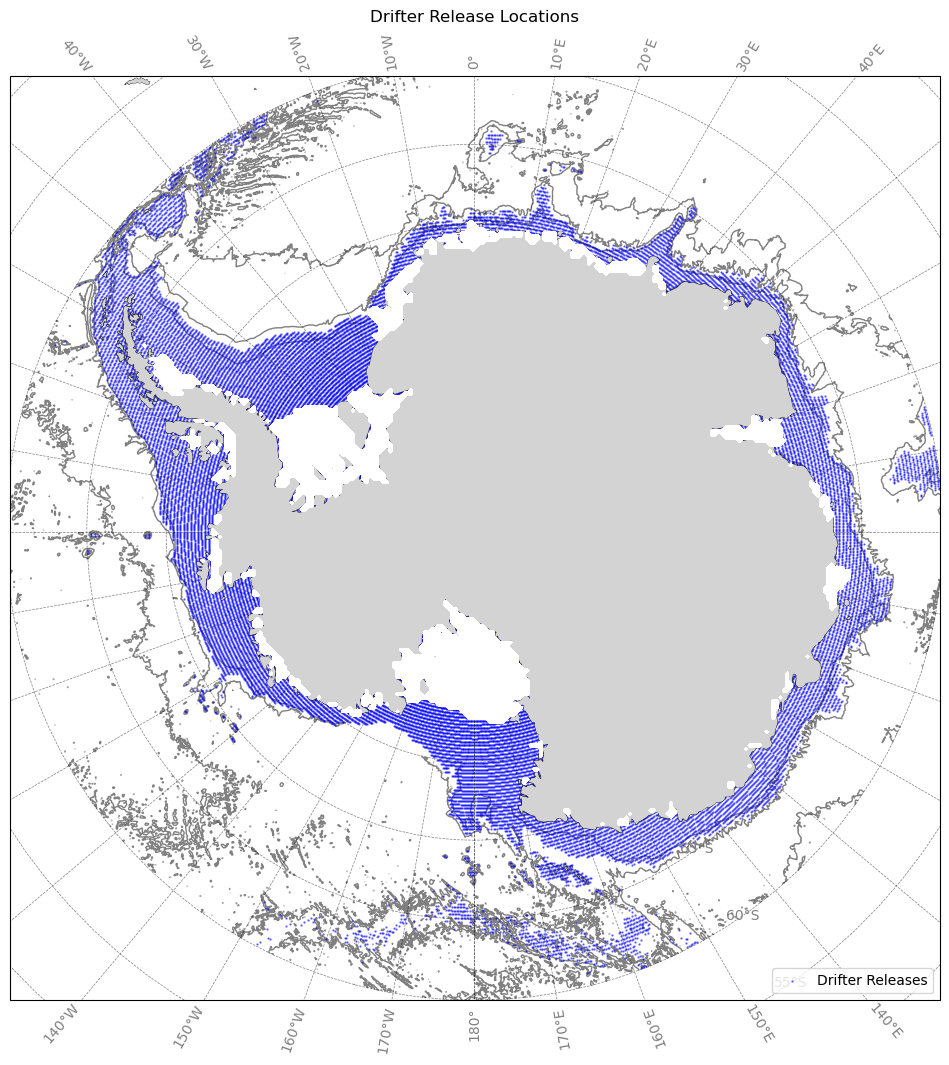

In [30]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import ticker

# Plot the drifter release grid with the ice shelf overlay
fig = plt.figure(figsize=(12, 12))
ax = plt.subplot(1, 1, 1, projection=ccrs.SouthPolarStereo())
# Set the extent for the Southern Ocean
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)  # Coastlines above most elements
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=3)  # Land above most elements

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=1)
gl.xlocator = ticker.FixedLocator(range(-180, 181, 10))
gl.ylocator = ticker.FixedLocator(range(-90, 91, 5))
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}

# Plot bathymetry contours (lowest layer)
contour = ax.contour(
    bathymetry_antcir['lon'], bathymetry_antcir['lat'], bathymetry_antcir,
    linestyles='solid', linewidths=1, colors='grey',
    transform=ccrs.PlateCarree(), zorder=0
)

# Plot the drifter release points (UNDER ice shelves)
ax.scatter(
    filtered_lon, filtered_lat,
    transform=ccrs.PlateCarree(),
    color='blue', s=0.5, alpha=0.5, label='Drifter Releases', zorder=1
)

# Overlay the ice shelf mask as a solid color (LAST to ensure it's on top)
ax.contourf(
    ds_ndic['x'], ds_ndic['y'], ice_shelf_mask,
    levels=[0.5, 1.5], colors=['white'], transform=ccrs.SouthPolarStereo(), zorder=4
)

# Add a legend
ax.legend(loc='lower right')

# Add a title
ax.set_title("Drifter Release Locations")
# Save the figure
plt.savefig(map_path + 'circumpolar-release-grid-ice.png', dpi=200, bbox_inches='tight')

plt.show()